In [1]:
# import libraries
import numpy as np
import pickle
import matplotlib.pyplot as plt
from adjustText import adjust_text
from utils import infinitesimal_generator, z_order_interactionsmem_transition_matrix
from utils_interaction_chain_viz import visualize_heatmap, labels_and_sizes_same

In [2]:
def load_and_visualize_heatmap(path, suptitle="", cbar_label=r'$Log_{10} (Pr[i \to j])$ over 100 ns', transform_transition_dt=-1, log_10=False, remove_fgs=[], dpi=300):

    with open(path, "rb") as f:
        tm, states = pickle.load(f)
    tm, states = z_order_interactionsmem_transition_matrix(tm, states) 
    if transform_transition_dt != -1: tm = infinitesimal_generator(tm, dt=transform_transition_dt)
    if log_10: tm = np.log10(tm)

    first_and_last_factor = 20
    # labels, label_sizes = labels_and_sizes(new_states, first_and_last_factor=first_and_last_factor)
    labels, label_sizes = labels_and_sizes_same(first_and_last_factor=first_and_last_factor)
    
    block_size = int(len(tm) / 2) 
    visualize_heatmap(tm[:block_size, :block_size],
                    suptitle=suptitle,
                    title="non mem states",
                    labels=labels,
                    label_sizes=label_sizes,
                    cbar_label=cbar_label,
                    first_and_last_factor=first_and_last_factor,
                    dpi=dpi)
    visualize_heatmap(tm[block_size:, block_size:],
                suptitle=suptitle,
                title="mem states",
                labels=labels,
                label_sizes=label_sizes,
                cbar_label=cbar_label,
                first_and_last_factor=first_and_last_factor,
                dpi=dpi)
    visualize_heatmap(tm,
                suptitle=suptitle,
                title="mem states",
                labels=labels,
                label_sizes=label_sizes,
                cbar_label=cbar_label,
                first_and_last_factor=first_and_last_factor,
                dpi=dpi)

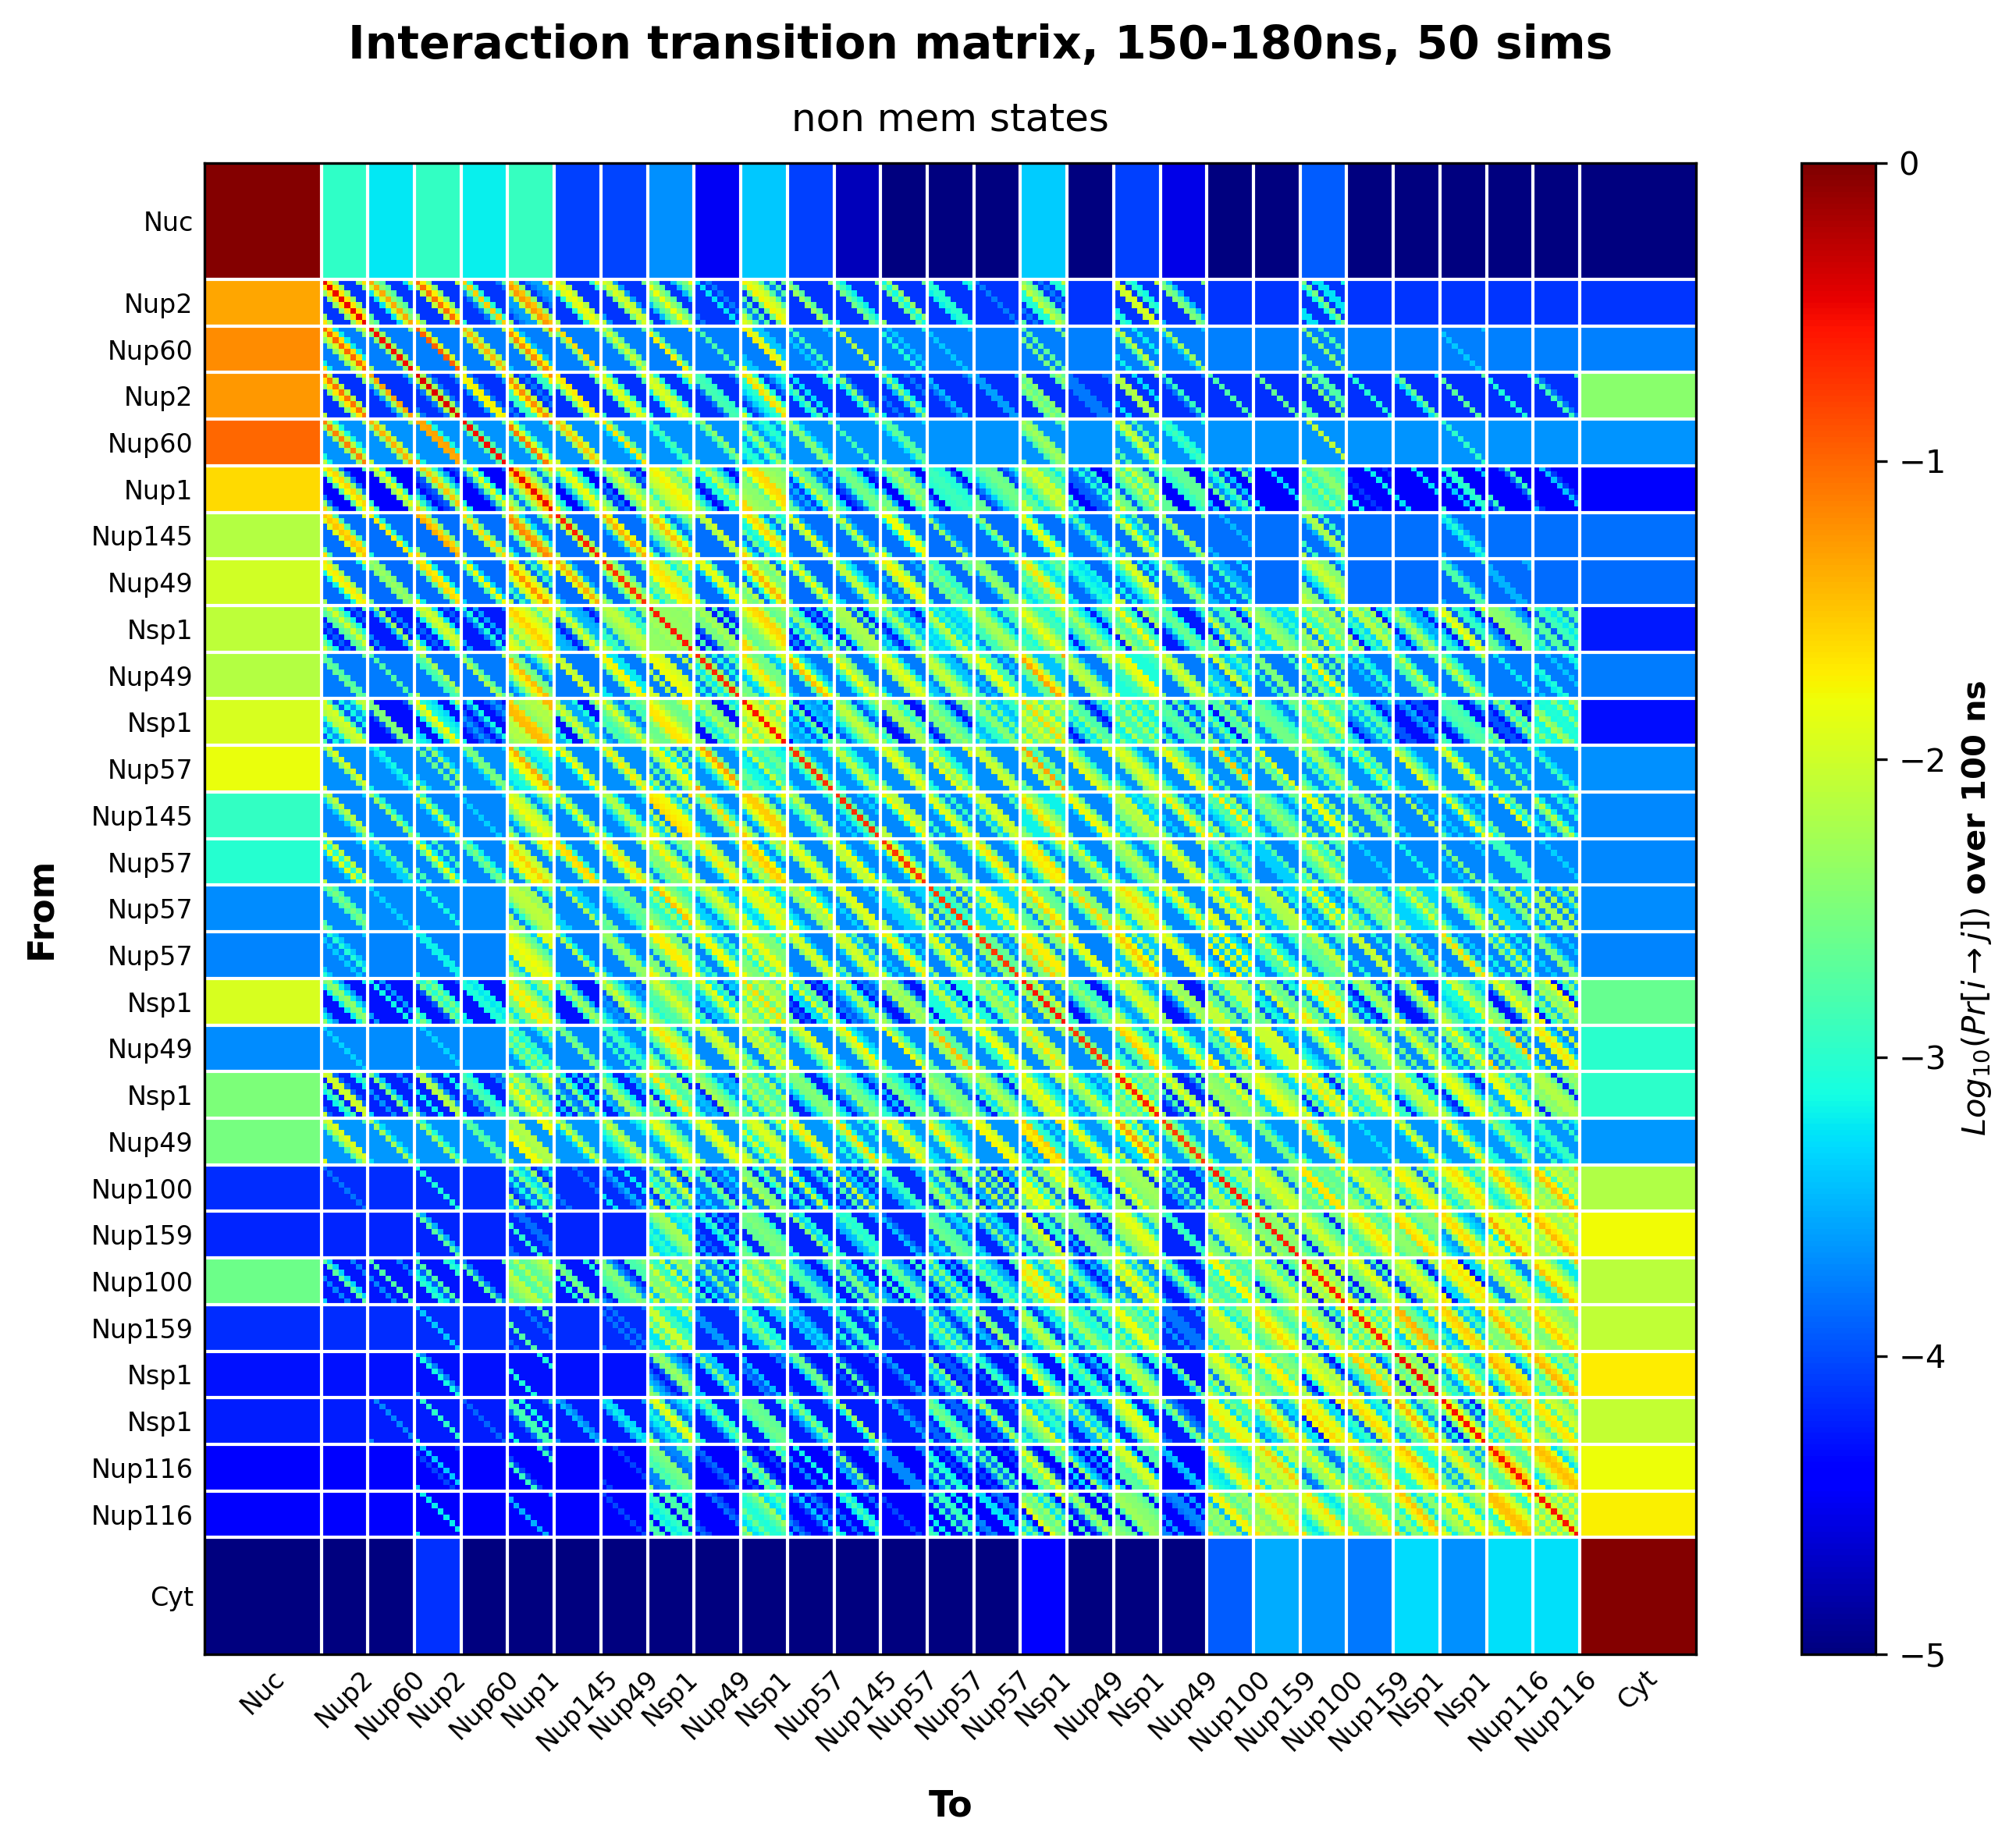

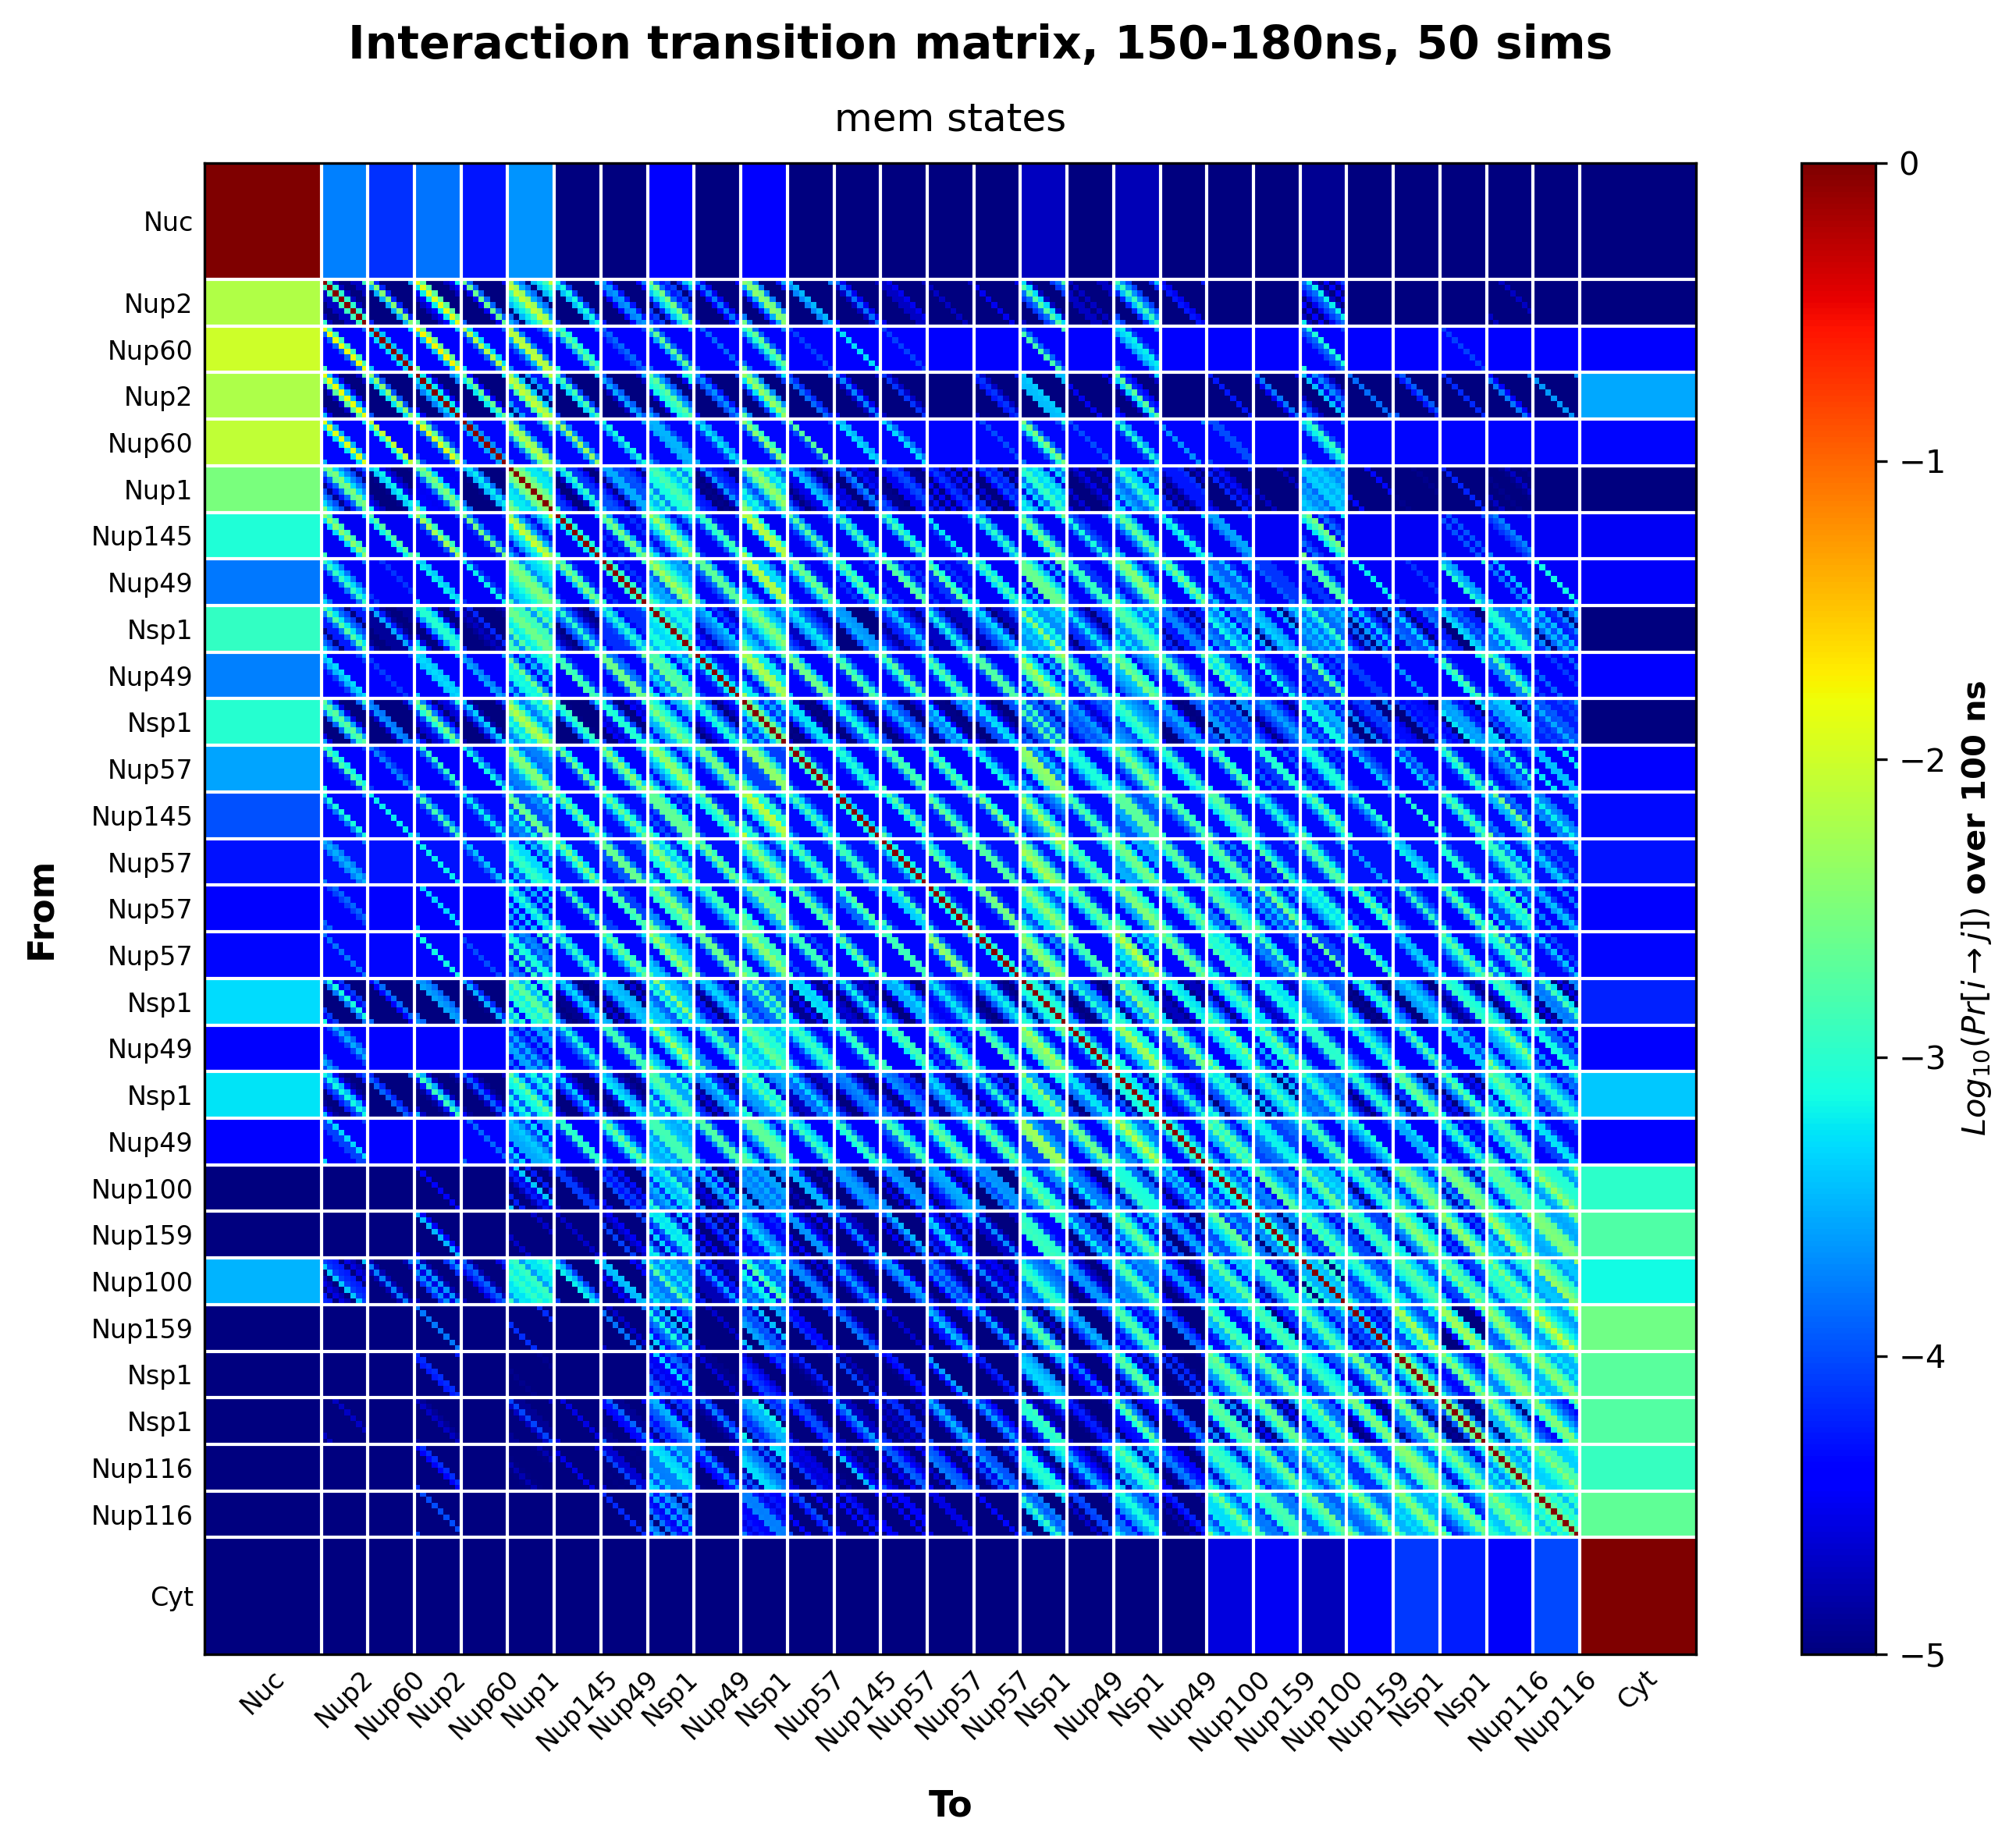

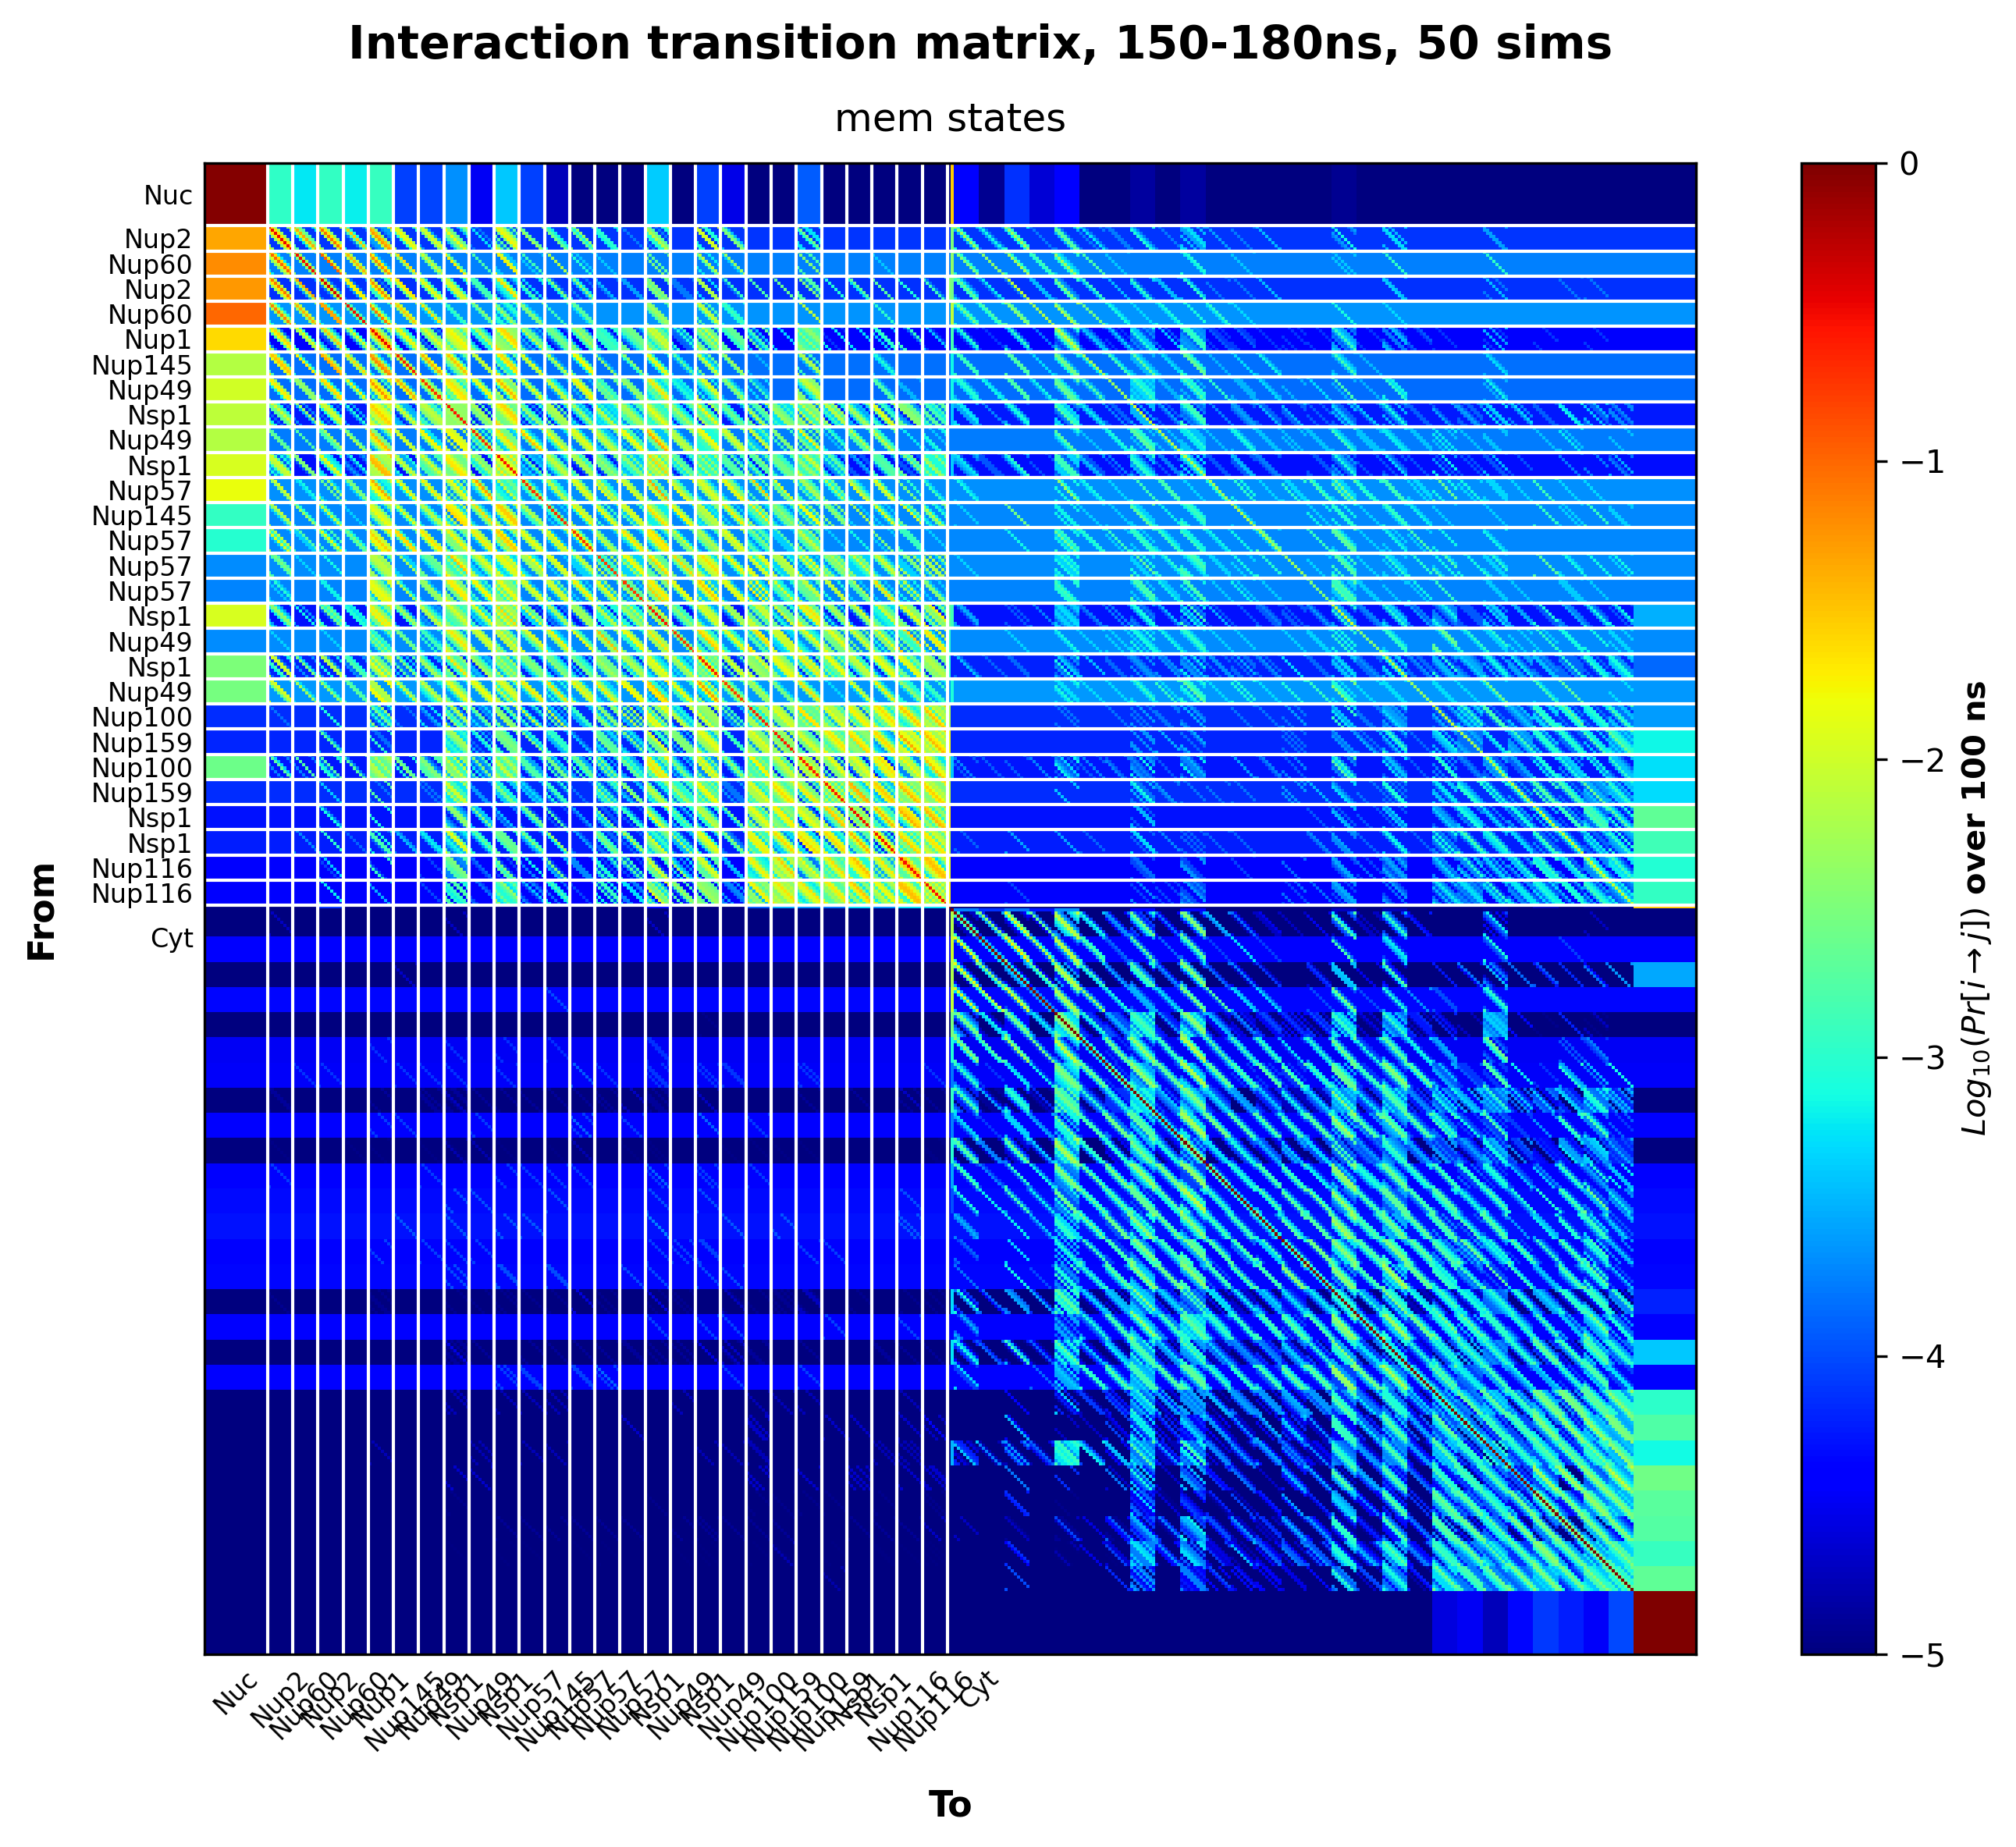

In [3]:
load_and_visualize_heatmap(f'data/transition_matrices/mem-with-0.1init/interactionsmem-window{32}-p{0.1}-150-180-100ns.pickle',
                               suptitle=f"Interaction transition matrix, 150-180ns, 50 sims",
                               cbar_label=r"$Log_{10} (Pr[i \to j])$ over 100 ns",
                               log_10=True)